# Raised-Cosine Filter

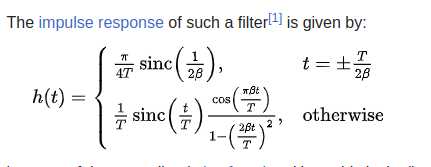

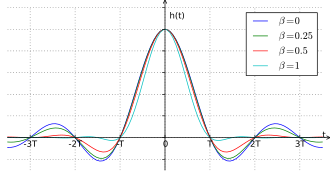



Reference: https://en.wikipedia.org/wiki/Raised-cosine_filter

https://wirelesspi.com/pulse-shaping-filter/

The Raised-Cosine (RC) filter is a widely used pulse-shaping filter in digital communication systems.
It is designed to limit the bandwidth of a transmitted signal while minimizing intersymbol interference (ISI).
The RC filter is characterized by its roll-off factor $\beta$, which controls the excess bandwidth beyond the Nyquist bandwidth.
Its frequency response has the shape of a cosine function that is 'raised' above zero, hence the name.
The ideal frequency response of the Raised-Cosine filter is given by:

\[
H(f) =
\begin{cases}
1, & |f| \leq \frac{1 - \beta}{2T}, \\[6pt]
\frac{1}{2} \left[ 1 + \cos \left( \frac{\pi T}{\beta} \left( |f| - \frac{1 - \beta}{2T} \right) \right) \right], & \frac{1 - \beta}{2T} < |f| \leq \frac{1 + \beta}{2T}, \\[6pt]
0, & |f| > \frac{1 + \beta}{2T},
\end{cases}
\]

where $T$ is the symbol period and $\beta \in [0,1]$ is the roll-off factor.
A smaller $\beta$ makes the filter bandwidth-efficient but harder to implement due to steeper transitions,
while a larger $\beta$ increases the bandwidth but provides smoother signal roll-off.
Thus, the RC filter is essential for ensuring that transmitted signals satisfy the Nyquist criterion for zero ISI.




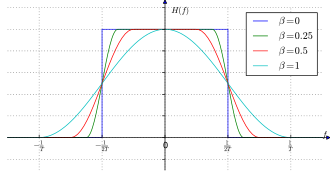

## Task 1: Generate raised cosine pulse

- Generate Raised-Coise Pulse with Parameters:
- samples per symbol = 16
- num_samples = 101  # Number of samples to be generated
- beta = 0.34

The impulse response of the raised cosine pulse is given by: $h(t) = \text{sinc}\left(t / T\right) \cdot \frac{\cos\left(\beta \pi t / T\right)}{1 - (2 \beta t / T)^2}$.

- Reference: https://pysdr.org/content/pulse_shaping.html

In [ ]:
# Write your code here
sps = 16

rc_pulse =

## Task 2: Plot Raised-Cosine Pulse

- Your Plot look like this




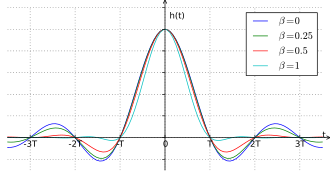

In [ ]:
# Write your code here



## Task 3: Plot Frequency Response of generated RC Pulse

1. **Normalize filter coefficients**
   - Scale h(t) so that total filter energy = 1.

2. **Compute FFT**
   - Take FFT of h(t) with large size (e.g., 2048 points).
   - This gives the frequency response H(f).

3. **Shift FFT**
   - Use fftshift to center zero frequency.

4. **Plot results**
   - Frequency domain: plot |H(f)| (linear or dB)


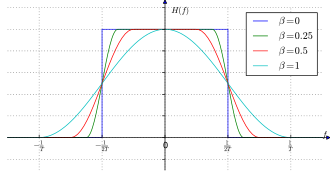

In [ ]:
# Write your code here



## Questions:

1. Is Raised-Cosine Pulse a Nyquist pulse?
2. What do you observe regarding the bandwidth and time-domain decay of pulse?
3. What is the role of $\beta$ in raised cosine pulse shaping? Mention what happens when you change the value of $\beta$ over $[0,~1]$.
4. After how many points do you see peak of the pulse ?


# Pulse Shaping


Reference: https://pysdr.org/content/pulse_shaping.html

## Task 1: Generate BPSK symbols

- Generate 100 Random bits

- Generate BPSK modulated symbols : BPSK symbols: -1 if bit = 0, and 1 if bit = 1


In [ ]:
# write your code here

message_bits =

bpsk_symbols =


## Task 2: Generate Zero padded BPSK sequence
- samples_per_symbol (SPS) =  8

- Create a new list with SPS-1 zeros after each symbol

- If BPSK symbols are
`array([-1, 1, 1, 1, 1, -1, -1, -1, 1, 1])`
then zero padded BPSK sequence look like below.

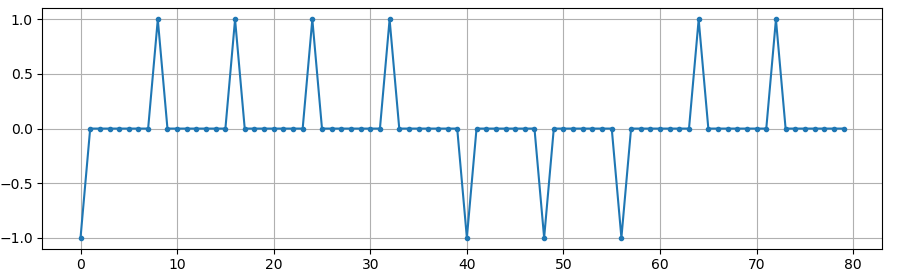

In [ ]:
#Write your code here

zero_padded_sequence =

## Task 3: Do pulse shaping above signal with generated Raised-Cosine Filter

- Pulse shaped signal = $s(t) * h(t)$, where $h(t)$ is the filter i.e., RC pulse, and * is convolution


In [ ]:
rc_pulse =  # assign generated RC pulse

pulse_shaped = np.convolve(zero_padded_sequence, rc_pulse, mode='full')



### Plot Pulse Shaped Signal

- Your Pluse Shaped signal look like this

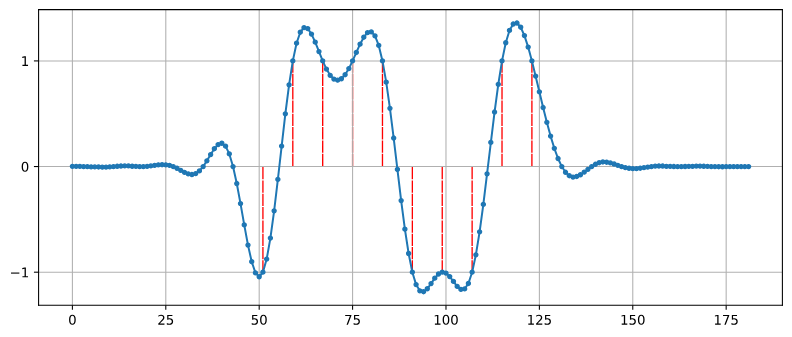



In [ ]:
# Write your code here



- Question: At what starting index do you see the samples of BPSK samples ?
- How to get back BPSK symbols from pulse shaped signal ?

## Task 4: Sampling

- Find the starting index of the original BPSK symbols in pulse shaped signal.

- From starting index sample from pulse shaped signal at every sps-th sample

In [ ]:
# Write your code here

start_index =

sampled_signal =


## Task 5: Decoding

- From samples signal, perform decoding as follows: map to bit 0 is symbol < 0, and map to bit 1 if symbol > 0

- Compare the decoded bits with original message bits, check wherether any error in decoding

In [ ]:
# Write your code here

decoded bits =



# Matched Filtering

Matched filtering is done by passing the received signal through a filter that is designed to match the pulse used at the transmitter. In simple terms, if the transmitter uses a raised-cosine pulse to shape the signal, the receiver uses the same raised-cosine pulse but flipped in time and conjugated. This process makes the useful signal line up and add together at the correct sampling instant, while noise and other unwanted parts do not add up strongly. As a result, the signal becomes clearer at the points where we need to sample it. This is why matched filtering is commonly used in digital communication systems—it ensures that the receiver samples the signal at the right points with maximum clarity and minimum noise effect.

Reference: https://en.wikipedia.org/wiki/Matched_filter

## Task 0: Pulse Shaping

- Generate random 100 message bits

-  Modulate them to BPSK symbols

- Create zero padded sequence from BPSK symbols

- Generate Pulse shaped signal

In [ ]:
# Write your code here






### Task 1: Introduce Noise
**- Generate Gaussian noise with mean zero and variance equal to `variance`. `variance` is a parameter that you can vary and see the performance later on. But do it for fixed value now.**

In [ ]:
import numpy as np

def generate_gaussian_noise(signal_length, mean, variance):
    noise = np.random.normal(mean, np.sqrt(variance), signal_length)
    return noise

mean = 0
variance = 2

# Use above function to generate noise
# siganl_length = length of pulse_shaped

noise =



### Plot Noise signal

In [ ]:
# Write your code here



### Task 2: AWGN Channel: Create a Noisy Signal
**- Add the pulse-shaped signal with the generated noise to create a noisy signal**.

 -  $y(t) = s(t) + w(t)$ , where $s(t)$ is pulse shaped signal, $w(t)$ is noise, $y(t)$ is received noisy signal

In [ ]:
# Write your code here

pulse_shaped =    #  y(t)----  assign your generated pulse shaped signal

rx_noisy =



### Plot received noisy signal (rx_noisy)

In [ ]:
# Write your code here




### Task 3: Apply Matched Filtering
- Do matched filtering to the noisy signal
-  $M_{filtered} =  (y(t) * h(-t))$, where $h(t)$ is the filter, i.e., Raised-cosine signal and * is convolution operation (use mode = 'full')


In [ ]:
# write your code here

# y(t) signal is rx_noisy signal
# h(t) is RC-filter
# Perform convolution operation to obtain matched filtered signal

h_t =         # h(t) assign filter here

rx_noisy=    # y(t)  assign received noisy signal her

M_filtered =

### Plot Matched Filtered signal

In [ ]:
# Write your code here






### Task 4: Compute SNR Values
- Compute the SNR before and after matched filtering. Use the following code snippet




In [ ]:
def compute_snr(signal, noise):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

# Write your code here
# Use above function to calculate SNR

SNR_before_filter =

SNR_after_filter =



- Question: At what starting index do you see the samples of transmitted BPSK samples ?
- How to get back BPSK symbols from matched filtered signal ?

## Task 5: Sampling

- Find the starting index of the original BPSK symbols in pulse matched filtered signal.

- From starting index sample from matched filtered signal at every sps-th sample

In [ ]:
# Write your code here

start_index =

sampled_signal =


## Task 6: Decoding

- From samples signal, perform decoding as follows: map to bit 0 is symbol < 0, and map to bit 1 if symbol > 0

- Compare the decoded bits with original message bits, check wherether any error in decoding

In [ ]:
# Write your code here

decoded bits =



### Task 7: Change Variance and repeat Task 1 to Task 6








## Questions

- What can you conclude about the SNR before and after matched filtering at the appropriate sampling intervals?
- How does matched filtering affect the probability of making errors in decision-making?
- In your opinion, how has matched filtering contributed to improving the communication system?
- (Think) Is it possible to continually apply matched filtering to keep improving SNR and completely eliminate noise, leading to zero errors?



# Problem of Imperfect Sampling

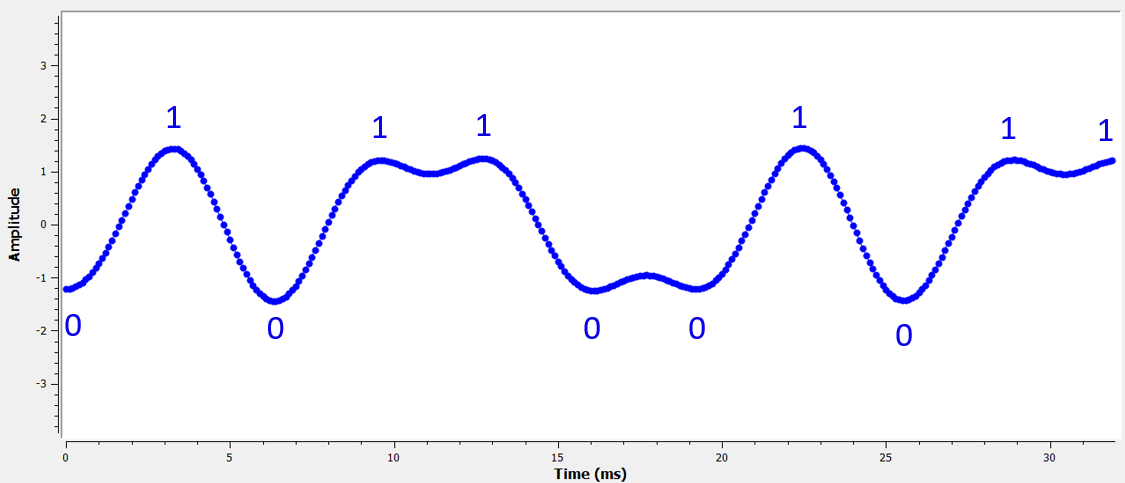

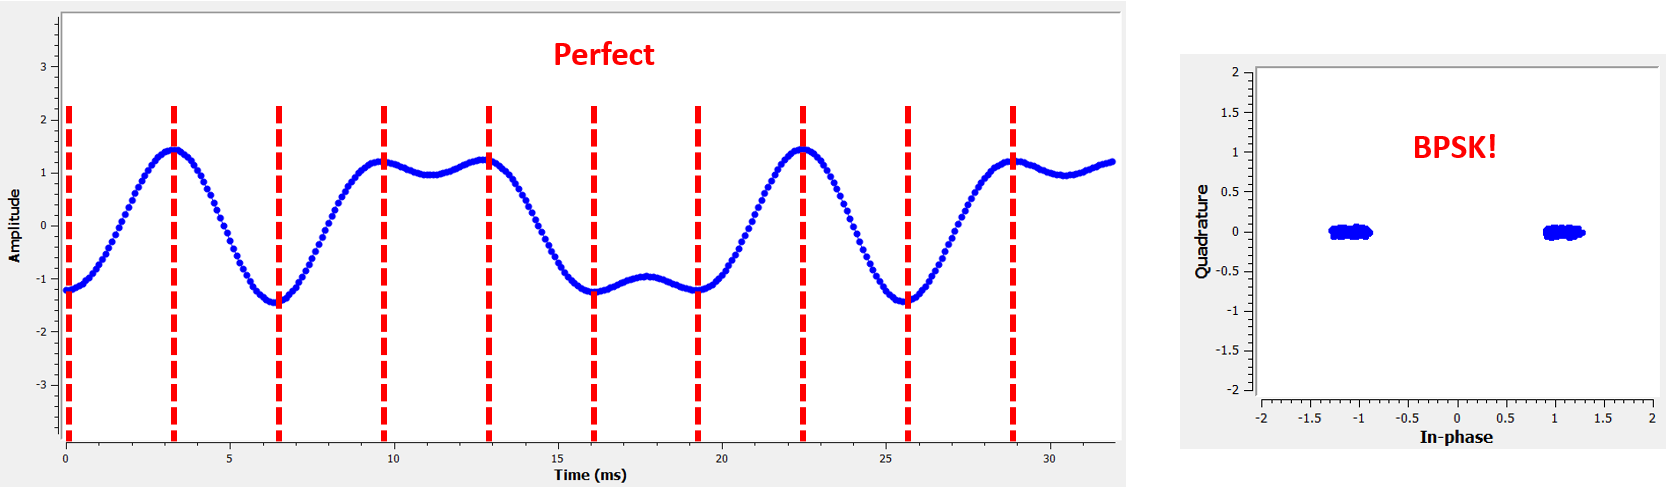

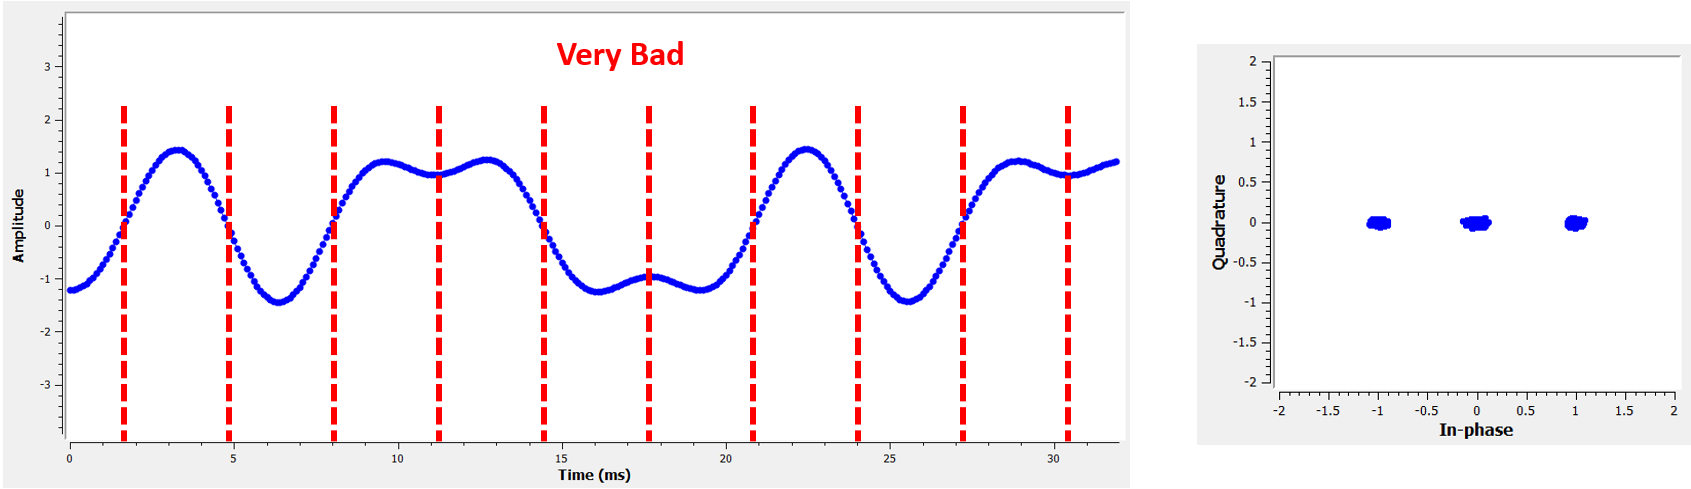

# Time Synchronization

Reference: https://pysdr.org/content/sync.html

- When we transmit a signal wirelessly, it arrives at the receiver with a random phase shift due to time traveled.
- We cannot just start sampling the symbols at our symbol rate because we are unlikely to sample it at the right spot in the pulse, as shown above.
- You can picture timing recovery as a block in the receiver, which accepts a stream of samples and outputs another stream of samples (similar to a filter). We program this timing recovery block with information about our signal, the most important being the number of samples per symbol (or our best guess at it, if we are not 100% sure what was transmitted).

- Most timing recovery methods rely on the fact that our digital symbols rise and then fall, and the crest is the point at which we want to sample the symbol. To put it another way, we sample the maximum point after taking the absolute value:

time-sync-output.svg

- Top Plot:
Original BPSK symbols, i.e., 1’s and -1’s. Recall that there are zeroes in between because we want 8 samples per symbol.

- Middle Plot:
Samples after pulse shaping but before the synchronizer.

- Bottom plot:
Output of the symbol synchronizer, which provides just 1 sample per symbol. That is these samples can be fed directly into a demodulator, which for BPSK is checking whether the value is greater than or less than 0.

time-sync-constellation.svg

### Mueller and Muller clock recovery technique

-  Reference: https://wirelesspi.com/mueller-and-muller-timing-synchronization-algorithm/

The Mueller and Muller (M&M) clock recovery technique is a popular method used in digital communication systems to correctly sample received signals. When a signal is transmitted, it can get distorted or shifted in time, so the receiver needs to figure out the right instant to pick each symbol. The M&M method does this by comparing the current symbol with the previous one and using their difference to adjust the timing. If the samples are taken too early or too late, the algorithm generates an error signal that shifts the sampling clock in the correct direction. Over time, this feedback keeps the sampling points aligned with the symbol centers, which helps reduce errors in detecting the transmitted bits. It is widely used because it works well even in noisy channels and does not require special training sequences.

# End-to-End Communication through SDRs

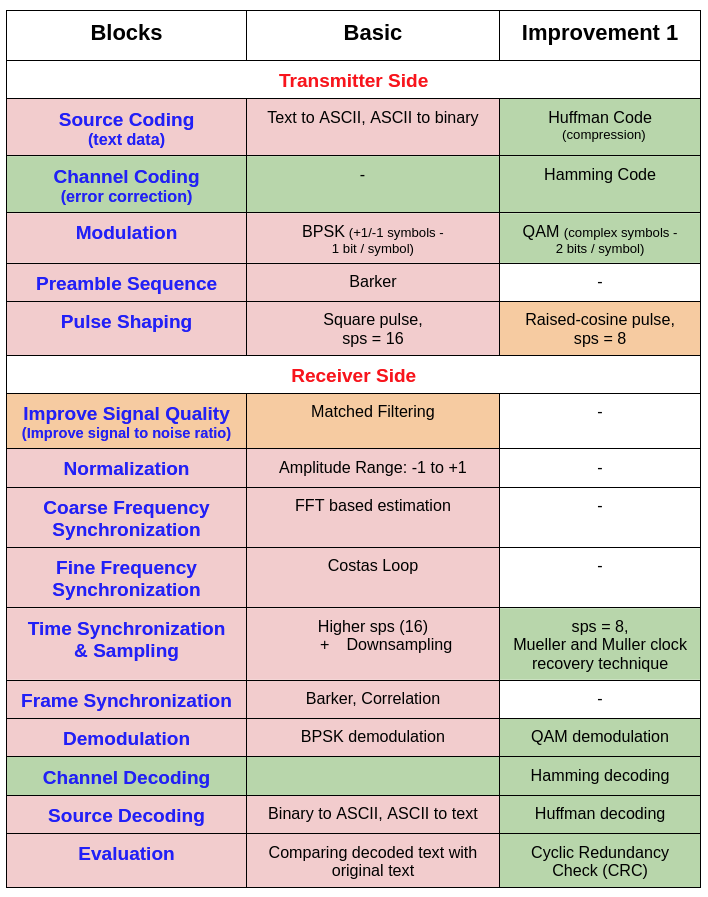



**- Some of these blocks may have already been coded by you during earlier lab sessions**



**-In today’s session, you learned the code implementation for the blocks shown in orange in the image (RC Pulse Shaping and Matched Filtering).**

**- In the upcoming lab sessions, you will focus on improving all the blocks, as highlighted in green in the image.**


# Tasks: End-to-End Communication System

- **Once you are able to successfully transmit and receive signals using two different SDRs, carry out the experiments on the complete end-to-end system as instructed below.**


## Task 1: Operating Frequency

- Change the operating frequency (same for both the transmitter and receiver SDRs) within the range of 400 MHz to 1300 MHz.

- Ensure that the chosen frequency is unique (for example: 459e6, 532e6, 689e6, …, 1343e6 Hz).

- Observe how the performance of the receiver blocks changes by analyzing the signal plots and scatter plots.

## Task 2: Distance

- Vary the distance between the transmitting and receiving SDRs.

- Begin with a very short distance and gradually increase it until you reach the maximum length allowed by the connected cables.

- Observe how the performance of the receiver blocks changes by analyzing the signal plots and scatter plots.


## Task 3: Incomplere Receiver System

- Disable (comment out) the code for each receiver block one at a time, while keeping the rest of the code active.

- For example: first disable the Matched Filtering block and run the system with the remaining blocks. Next, enable Matched Filtering but disable only the Normalization block, and so on.

- Repeat this process for all receiver blocks individually.

- Observe how the performance of the receiver changes by analyzing the signal plots and scatter plots.

## Task 4: Broadcast

- Re-enable all the receiver blocks that were disabled (commented out) in the previous experiment, so the complete receiver system is active.

- Set up the system to transmit with a single SDR and receive with two separate SDRs.

- Collaborate with your adjacent labmate to perform this experiment.

- In this setup, the transmitter acts as a broadcaster, transmitting to multiple receivers.

- Use a copy of the receiver notebook to operate the second SDR.

- Configure both receiver SDRs to the same frequency as the transmitter.

- Attempt to receive and successfully decode the signal at both receiving SDRs.


## Task 5: Multiple Access

- Perform the reverse of broadcasting: transmit using two different SDRs at the same frequency and receive with a single SDR.

- Collaborate with your adjacent labmate to carry out this experiment.

- In this setup, the receiver acts as an access point, receiving signals from multiple transmitters.

- Use a copy of the transmitter code for the second SDR.

- Configure both transmitters with different text messages of the same length.

- At the receiver side, attempt to receive and decode the transmitted messages.

- Check whether you are able to successfully decode any one of the text messages.

- If not, observe how the signal from the second transmitter interferes with the main transmitter in the receiver blocks by analyzing the signal plots and scatter plots.



## Task 6: Vary  Parameters
- Perform this experiment with a complete end-to-end system using one transmitting SDR and one receiving SDR (no broadcasting or multiple access).

- Vary the following parameters one by one, and observe the impact on the performance of the receiver blocks through signal plots and scatter plots:

1) Text message length – changing this alters the number of message bits.

2) Barker code length – try values other than the standard length of 13.

3) Number of taps in the RC pulse.

4) Samples per symbol (sps).

5) Transmitter hardware gain – set with `sdr.tx_hardwaregain_chan0`, vary between –90 dB to 0 dB.

6) Transmit signal amplitude – replace the default 2^14 with other values.

## Task 7: Transmission Medium (Wireless / Wired)

- Instead of using wireless transmission, directly connect the transmitting SDR to the receiving SDR using a coaxial cable.

- The required cable is provided in the SDR kit.

- Observe the changes in the performance of the receiver blocks by analyzing the signal plots and scatter plots.
